<a href="https://colab.research.google.com/github/AkilaliBeig/AI_Machine_Learning/blob/main/Transfer%20Learning/Transfer%20Learning%20Model%20for%20MNIST%20dataset%20with%20Image%20Classification%20and%20Regression(Image%20Bounding).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mounting the drive to load the data from drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip -q "/content/drive/MyDrive/Colab Notebooks/MNIST_Object_Detection.zip"

In [3]:
import os                                 # Importing os module to get the path
from os import listdir                    # Importing listdir module to get the list of directories or files
import numpy as np                        # Imporing numpy for numerical operations
import pandas as pd                       # importing pandas to read csv or txt files
import matplotlib.pyplot as plt           # Importing Matplolib for ploting graphs and visualizing images
import cv2                                # importing opencv to work on images
import seaborn as sns                     # importing seaborn for data visualization
import tensorflow as tf                   # Importing tensorflow for tensor operations or model building
import keras                              # Importing keras for model building
from tensorflow.keras.models import Sequential, Model                 # sequential api for sequential model
from tensorflow.keras.layers import Dense, Dropout, Flatten           # Importing different layers like dense and flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Input, Activation # importing CNN layers and activations
from tensorflow.keras import backend                                  # Importing backend module to clear backend
from tensorflow.keras.utils import to_categorical                     # Importing to_categorical to perform one-hot encoding
from tensorflow.keras.optimizers import RMSprop,Adam,SGD #Importing optimiers for optimizing the model
from tensorflow.keras.callbacks import EarlyStopping  # regularization method to prevent the overfitting
from tensorflow.keras import losses, optimizers       # importing losses and optimizers from keras
from google.colab.patches import cv2_imshow           # importing cv2_imshow to display images

from sklearn.metrics import mean_absolute_error,mean_squared_error     # importing the error metrics for regression
from sklearn.metrics import accuracy_score, confusion_matrix           # importing the error metrics for classification

# Importing the transfer learning model- VGG16
from tensorflow.keras.applications import VGG16

In [4]:
##Function to store training data in a list
def create_training_data():
  training_data = []                                                            # Creating a list to store the training data
  IMG_SIZE=300                                                                  # initializing image size to 300
  # get the path/directory
  folder_dir = "/content/mnist_detection/train/images"                          # path for training images directory
  dirpath = "/content/mnist_detection/train/labels"                             # path for training labels directory

  list_dir=[int(file.split(".")[0]) for file in os.listdir(folder_dir)]         # separating the image name from extension and storing it in a list like 0.png is stored as 0 and 99.png is stored as 99.
  list_dir.sort()                                                               # sorting the image names in ascending order starting from 0

  label_dir=[int(file.split(".")[0]) for file in os.listdir(dirpath)]           # separating the label name from extension and storing it in a list like 0.txt is stored as 0 and 99.txt is stored as 99.
  label_dir.sort()                                                              # sorting the label names in ascending order starting from 0

  for images,filename,i in zip(list_dir,label_dir,range(10000)):
            data = pd.read_csv((os.path.join(dirpath+'/' + str(filename)+".txt")), sep=',',  header=0)      # Reading each txt file with header as 0th row and each value is separated by comma.

            # Storing the four bounding boxes
            xmin=data['xmin'].values[0]
            xmax=data['xmax'].values[0]
            ymin=data['ymin'].values[0]
            ymax=data['ymax'].values[0]

            img_array = cv2.imread(os.path.join(folder_dir+'/' + str(images)+".png"))                       # Reading the image
            # Resizing each image to image_size=300 as we require each image to be of the same size before training the model without missing any image of a different size
            new_array = cv2.resize(img_array,(IMG_SIZE,IMG_SIZE))
            training_data.append([new_array,data['label'].values[0],(xmin,ymin,xmax,ymax)])                 # Appending the image array,
  return training_data

# calling the create_training_data function
training_data=create_training_data()

In [5]:
# Function to create testing data
def create_testing_data():
  testing_data = []
  IMG_SIZE=300
  # get the path/directory
  folder_dir = "/content/mnist_detection/test/images"
  dirpath = "/content/mnist_detection/test/labels"

  list_dir=[int(file.split(".")[0]) for file in os.listdir(folder_dir)]
  list_dir.sort()


  label_dir=[int(file.split(".")[0]) for file in os.listdir(dirpath)]
  label_dir.sort()

  for images,filename,i in zip(list_dir,label_dir,range(10000)):
            data = pd.read_csv((os.path.join(dirpath+'/' + str(filename)+".txt")), sep=',',  header=0)

            xmin=data['xmin'].values[0]
            xmax=data['xmax'].values[0]
            ymin=data['ymin'].values[0]
            ymax=data['ymax'].values[0]

            img_array = cv2.imread(os.path.join(folder_dir+'/' + str(images)+".png"))
            new_array = cv2.resize(img_array,(IMG_SIZE,IMG_SIZE))
            testing_data.append([new_array,data['label'].values[0],(xmin,ymin,xmax,ymax)])
  return testing_data

testing_data=create_testing_data()

In [6]:
#Splitting the images, labels and bounding boxes
X_train = []
y_train = []
X_test = []
y_test = []
y_train_boxes=[]
y_test_boxes=[]

for features,labels,boxes in training_data:                                     # Iterating over the training data which is generated from the create_training_data() function
    X_train.append(features)                                                    # Appending images into X_train
    y_train.append(labels)                                                      # Appending labels to y_train
    y_train_boxes.append(boxes)                                                 # Appending bounding boxes to y_train_boxes

for features,labels,boxes in testing_data:                                      # Iterating over the testing data which is generated from the create_testing_data() function
    X_test.append(features)                                                     # Appending images into X_test
    y_test.append(labels)                                                       # Appending labels to y_test
    y_test_boxes.append(boxes)

In [7]:
# Converting the lists to numpy arrays and reshaping them to (300,300,3)
X_train=np.array(X_train).reshape(np.array(X_train).shape[0],300,300,3)
X_test=np.array(X_test).reshape(np.array(X_test).shape[0],300,300,3)

In [8]:
X_train.shape

(10000, 300, 300, 3)

In [9]:
X_train.shape[0]

10000

In [10]:
# scaling bounding box relative to image size
y_train_boxes_scaled=[]    # list to stored the scaled bounding boxes
y_test_boxes_scaled=[]     # list to stored the scaled bounding boxes
IMG_SIZE=300

# Scaling the train_boxes
for boxes in y_train_boxes:
  value = tuple(i/IMG_SIZE for i in boxes)
  y_train_boxes_scaled.append(value)

# Scaling the test_boxes
for boxes in y_test_boxes:
  value = tuple(i/IMG_SIZE for i in boxes)
  y_test_boxes_scaled.append(value)

Text(0.5, 1.0, 'Image corresponds to: 4')

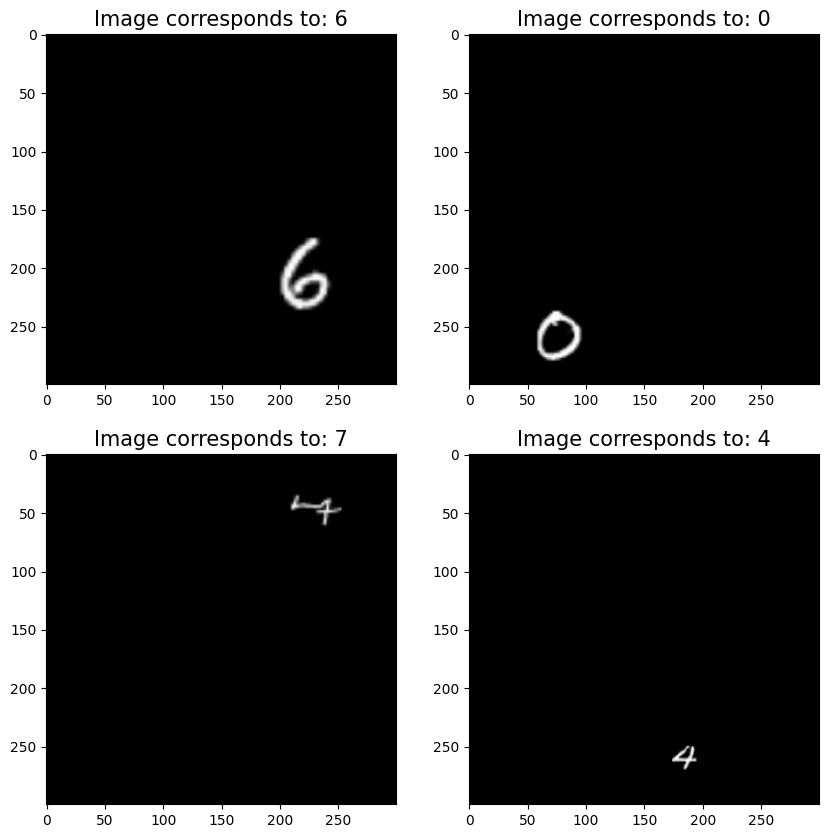

In [11]:
# f = plt.figure(figsize=(100,100))
f, axarr = plt.subplots(2,2,figsize=(10,10))
axarr[0,0].imshow(X_train[100])
axarr[0,0].set_title("Image corresponds to: " + str(y_train[100]),{'fontsize':15})
axarr[0,1].imshow(X_train[200])
axarr[0,1].set_title("Image corresponds to: " + str(y_train[200]),{'fontsize':15})
axarr[1,0].imshow(X_train[300])
axarr[1,0].set_title("Image corresponds to: " + str(y_train[300]),{'fontsize':15})
axarr[1,1].imshow(X_train[400])
axarr[1,1].set_title("Image corresponds to: " + str(y_train[400]),{'fontsize':15})

In [12]:
## Visualizing the Bounding Boxes
def plot_boxes(index):
  (startX, endX,startY, endY) = y_train_boxes_scaled[index]                     # Getting the coordinates of the boxes
  images = X_train[index]                                                       # Getting the image
  (h, w,_) = X_train[0].shape                                                   # Getting the height and width

  # Getting the coordinates to original height and width
  startX = int(startX*w)
  startY = int(startY*h)
  endX = int(endX*w)
  endY = int(endY*h)

  label = y_train[index]                                                        # Getting the label
  imgHeight, imgWidth, _ = images.shape                                         # Getting the height and width of the image
  thick = int((imgHeight + imgWidth) // 900)                                    # Giving a random thickness value for the rectangle
  color = (0,255,0)                                                             # Giving a color to the rectangle box

  # plotting the rectangle on the image with title
  cv2.rectangle(images,(startX, startY), (endX, endY), (0,255,0), thick)            # Plotting the rectangle box on the image
  cv2.putText(images, str(label), (startX, startY - 12), 0, 1* imgHeight, color)
  plt.title("Image corresponds to: " + str(label),{'fontsize':15})
  plt.imshow(images)



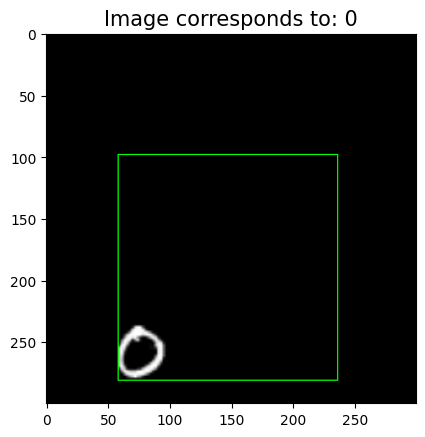

In [13]:
plot_boxes(200)

In [14]:
X_train[0].shape

(300, 300, 3)

In [15]:
(startX, endX,startY, endY) = y_train_boxes_scaled[0]
print(startX)
print(endX)
print(startY)
print(endY)


0.9
0.87
0.9433333333333334
0.9333333333333333


In [16]:
 label = y_train[0]
 label

np.int64(6)

In [17]:
images = X_train[0]
images.shape

(300, 300, 3)

In [18]:
# Converting the list into DataFrame to define the label column so that this can be used along with its axis during predictions and the dataframe operations can be easily implemented
y_train = pd.DataFrame(y_train, columns=["Label"],dtype=object)
y_test = pd.DataFrame(y_test, columns=["Label"],dtype=object)

In [23]:
y_train

,Label
0,6
1,2
2,4
3,8
4,6
...,...
9995,4
9996,7
9997,6
9998,4


In [24]:
# Storing the value counts of target variable
count=y_train.Label.value_counts()
print(count)
print('*'*10)
count=y_train.Label.value_counts(normalize=True)
print(count)

Label
1    1062
3    1044
9    1039
8    1018
7    1018
6    1001
4     985
0     968
2     941
5     924
Name: count, dtype: int64
**********
Label
1    0.1062
3    0.1044
9    0.1039
8    0.1018
7    0.1018
6    0.1001
4    0.0985
0    0.0968
2    0.0941
5    0.0924
Name: proportion, dtype: float64


In [25]:
#Converting the target features into arrays
y_train=y_train.astype('float')
y_test=y_test.astype('float')

# Converting the pixel values into Numpy array as arrays are computationally faster as compared to lists
y_train_boxes_scaled= np.array(y_train_boxes_scaled,dtype='float32')
y_test_boxes_scaled= np.array(y_test_boxes_scaled,dtype='float32')

In [26]:
from tensorflow.keras import backend
backend.clear_session()
np.random.seed(42)
import random
random.seed(42)
tf.random.set_seed(42)

In [27]:
def get_model():

    # Using the VGG16 model to implement transfer learning
    # We are defining include_top=false to remove the dense layers from the VGG16 model
    vgg = VGG16(weights="imagenet", include_top=False, input_tensor=Input(shape=(300, 300, 3)))
    # Freezing all VGG layers so they will *not* be updated during the training process
    vgg.trainable = False
    # flatten the max-pooling output of VGG16 so that we can add the required dense layers to the model.
    flatten = vgg.output
    x = Flatten()(flatten)

    # Adding a classification layer to classify the labels
    classifier_head = Dropout(0.3)(x)
    # Adding a output layer for labels with 10 neurons
    classifier_head = Dense(10, activation='softmax', name='label')(classifier_head)

    # Adding a Regression layer to predict the bounding boxes
    reg_head = Dense(128, activation='relu')(x)
    reg_head = Dense(64, activation='relu')(reg_head)
    reg_head = Dense(32, activation='relu')(reg_head)
    reg_head = Dense(16, activation='relu')(reg_head)
    # Adding the output layer to output 4 regression outputs for bounding boxes
    reg_head = Dense(4, activation='sigmoid', name='bbox')(reg_head)

    return Model(inputs=vgg.input, outputs=[classifier_head, reg_head])



# Calling the get_model() function
model=get_model()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [28]:
# Plotting the summary of the model
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 300, 300,  │      1,792 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 300, 300,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 150, 150,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 150, 150,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 150, 150,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 75, 75,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 75, 75,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 75, 75,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 75, 75,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 37, 37,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 37, 37,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 37, 37,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 37, 37,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 18, 18,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 18, 18,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 18, 18,    │  2,359,808 │ block5_conv1[0][

 Total params: 20,448,894 (78.01 MB)

 Trainable params: 5,734,206 (21.87 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [29]:
# Using SGD optimizer with momentum as it generalizes better than other optimizers like Adam
opt = SGD(learning_rate=0.01,momentum=0.94)
model.compile(optimizer=opt, loss=['sparse_categorical_crossentropy','mse'])

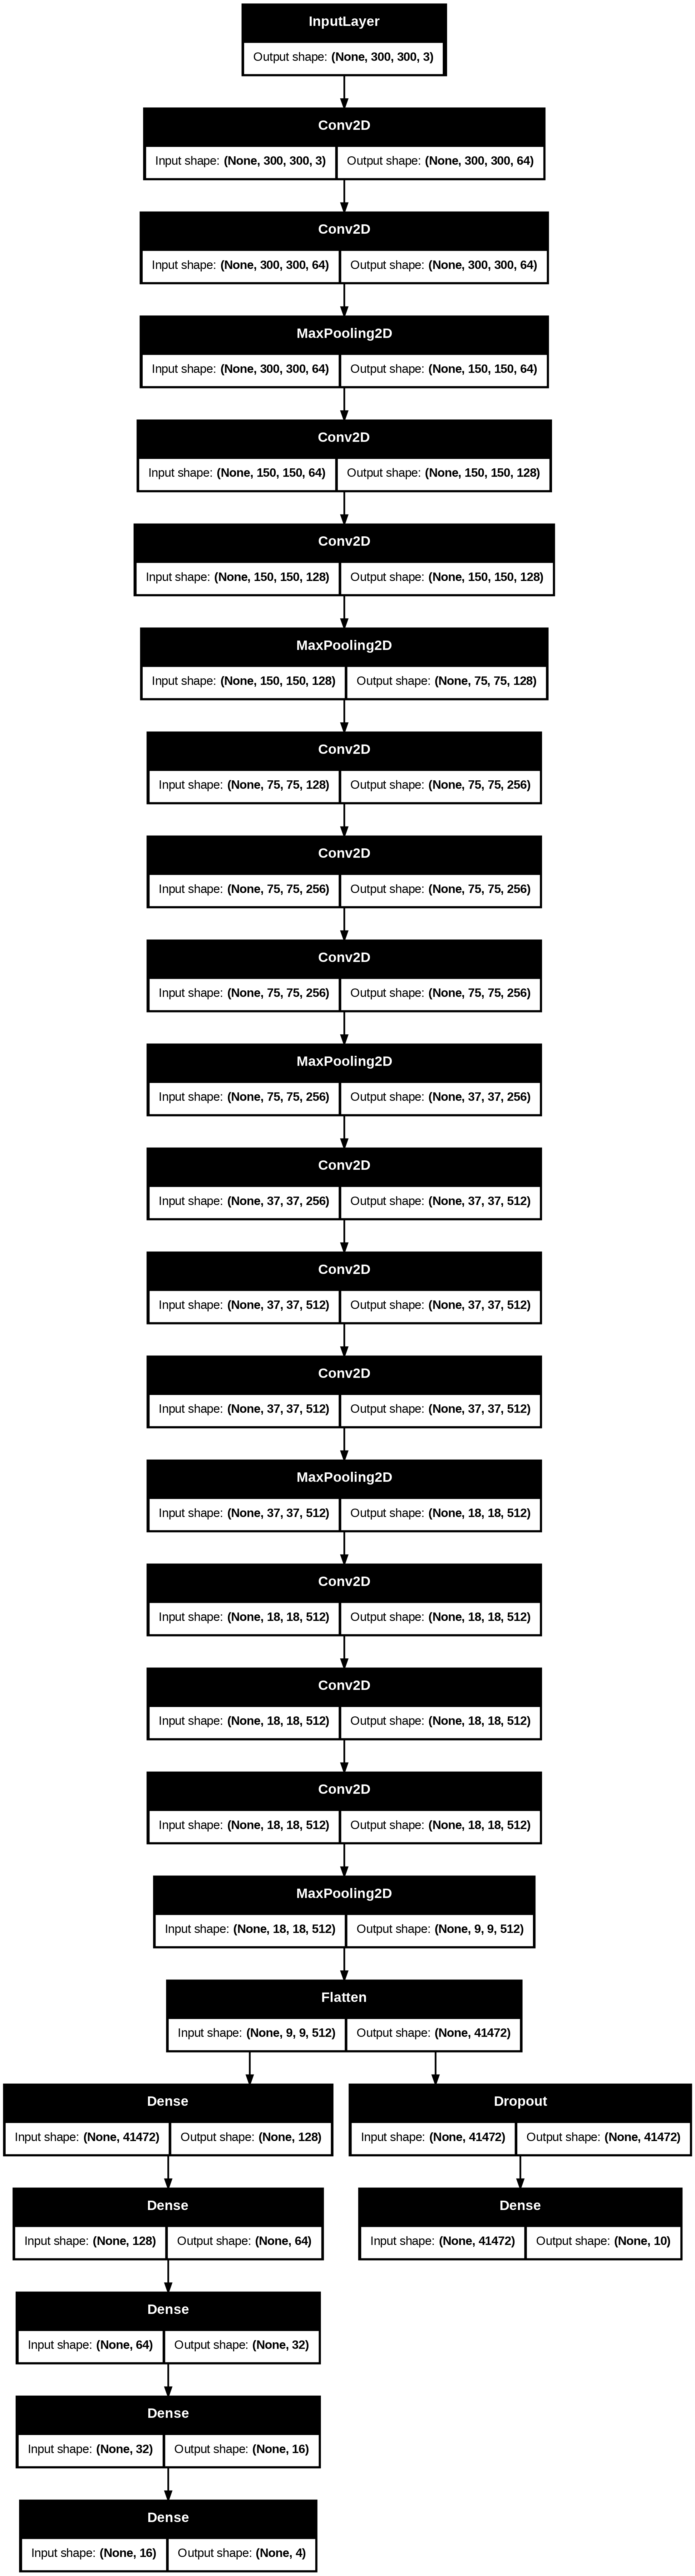

In [30]:
 # plotting the model architecture
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model.png', show_shapes=True)

In [31]:
# Fitting the model with 10 epochs and validation_split as 10%
history=model.fit(X_train,
          [y_train,y_train_boxes_scaled],
          epochs=10,
          batch_size=64,validation_split=0.1)

Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 178s 976ms/step - bbox_loss: 0.0369 - label_loss: 255.5843 - loss: 255.6247 - val_bbox_loss: 0.0100 - val_label_loss: 193.2997 - val_loss: 192.8900
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 126s 714ms/step - bbox_loss: 0.0063 - label_loss: 220.4449 - loss: 220.4539 - val_bbox_loss: 0.0026 - val_label_loss: 194.0666 - val_loss: 193.6194
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 142s 714ms/step - bbox_loss: 0.0023 - label_loss: 188.6931 - loss: 188.6977 - val_bbox_loss: 0.0019 - val_label_loss: 186.1633 - val_loss: 187.3509
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 142s 713ms/step - bbox_loss: 0.0016 - label_loss: 150.4730 - loss: 150.4756 - val_bbox_loss: 0.0016 - val_label_loss: 199.9706 - val_loss: 199.1876
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 142s 715ms/step - bbox_loss: 0.0013 - label_loss: 144.5739 - loss: 144.5759 - val_bbox_loss: 0.0013 - val_label_loss: 210.4400 - val_loss: 210.2923
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 100s 710ms/step - bb

In [32]:
yhat1, yhat2 = model.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 44s 677ms/step


In [47]:
yhat1[0:3]

array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [46]:
yhat2[0:5]

array([[0.46746162, 0.3152714 , 0.5962387 , 0.4369285 ],
       [0.6650626 , 0.1775337 , 0.84899664, 0.36988395],
       [0.864436  , 0.7520956 , 0.9102406 , 0.82089293],
       [0.14342521, 0.08889901, 0.26853105, 0.22225861],
       [0.15685304, 0.33967045, 0.22747736, 0.4772226 ]], dtype=float32)

In [39]:

# Obtaining the class from the onehot encoded output
yhat1_classes=np.argmax(yhat1,axis=1)

In [48]:
yhat1_classes[:3]

array([6, 3, 3])

In [49]:
# calculate Mean_Absolute_Error for regression model/ bounding boxes
mae = mean_absolute_error(y_test_boxes_scaled, yhat2)
print('MAE: %.3f' % mae)

# calculate Mean_Squared_Error for regression model/ bounding boxes
mse = mean_squared_error(y_test_boxes_scaled, yhat2)
print('MSE: %.3f' % mse)

MAE: 0.024
MSE: 0.001


In [52]:
# evaluate accuracy for classification model/ labels
acc = accuracy_score(y_test['Label'], yhat1_classes)
print('Accuracy: %.3f' % acc)

Accuracy: 0.670


In [53]:
# Plotting the confusion matrix
cf_matrix = confusion_matrix(y_test['Label'], yhat1_classes)
cf_matrix

array([[ 71,   0,   0,   3,   0,   0,  11,   0,   0,   8],
       [  0, 124,   1,   0,   1,   0,   0,   0,   0,   0],
       [  1,   1,  58,  11,   9,   7,   7,   1,   7,   6],
       [  0,   1,   9,  69,   0,  13,   8,   0,   6,   5],
       [  0,   4,   3,   5,  69,   1,   2,   1,   2,  11],
       [  4,   0,   6,  16,   4,  44,   5,   0,   2,   3],
       [  6,   2,   2,   2,   1,   1,  58,   0,   3,   4],
       [  0,   3,   9,   6,  24,   2,   2,  45,   0,  18],
       [  1,   0,   5,  11,   3,   3,   8,   1,  60,   8],
       [  3,   1,   5,   2,   2,   0,   3,   0,   4,  72]])

<Axes: >

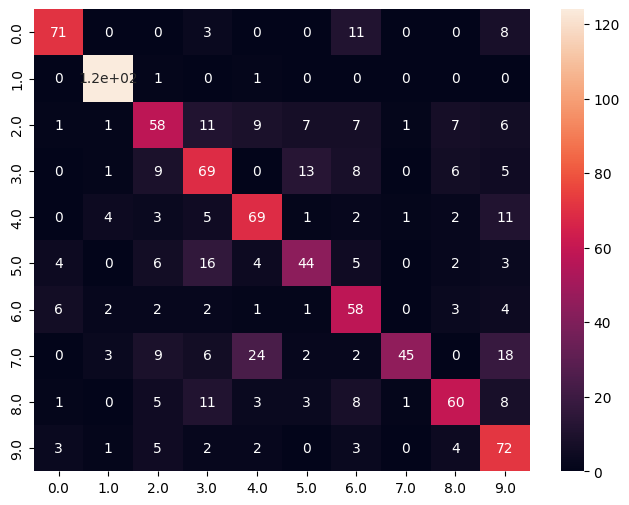

In [55]:
plt.figure(figsize=(8,6))
sns.heatmap(cf_matrix, xticklabels=np.unique(y_test['Label']), yticklabels=np.unique(y_test['Label']), annot=True)

<Axes: >

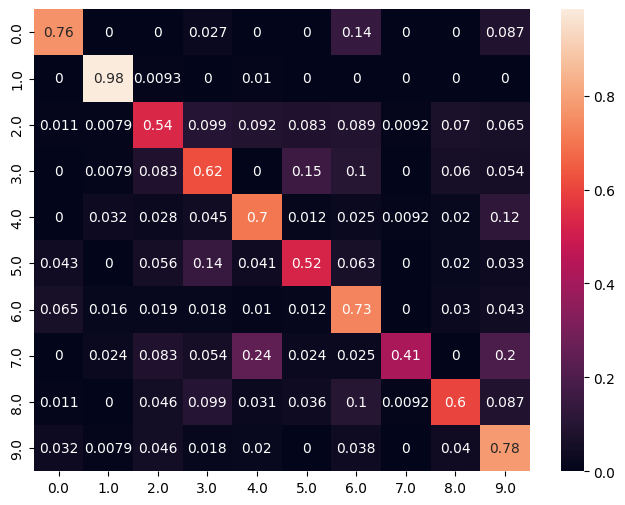

In [56]:

# Confusion matrix normalized per category true value
cf_matrix_n1 = cf_matrix/np.sum(cf_matrix, axis=1)
plt.figure(figsize=(8,6))
sns.heatmap(cf_matrix_n1, xticklabels=np.unique(y_test['Label']), yticklabels=np.unique(y_test['Label']), annot=True)